In [1]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

In [2]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

FileMap = dict[str, dict[str, str]]
csi_map = dict[str, dict[str, dict[str, np.ndarray]]]


data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id = sort_meta_info(path)
print(f"Scenarios: {scenarios_id}")
print(f"Users: {users_id}")
print(f"Activities: {activities_id}")
print(f"ESPs: {esps_id}")
print("\nData files: ", data_files)

Scenarios: ['00']
Users: ['01']
Activities: ['00']
ESPs: ['02', '03']

Data files:  {'scenario_00': {'user_00': {'activity_01': {'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/00_00_01_02_2026-02-25.csv')], 'esp_03': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/00_00_01_03_2026-02-25.csv')]}}}}


In [3]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid division by zero
    return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
	pca = PCA(n_components=variance_ratio)
	transformed = pca.fit_transform(magnitude_data)
	return transformed, pca


def process_csi(data_file: str) -> np.ndarray:

	file_csv = pd.read_csv(data_file, header=None)

	# number of samples
	csi_raw: pd.Series = file_csv.iloc[:, 25]

	total_sc: int = 128
	valid_csi: list[list[float]] = []

    # contar CSI inválidos
	no_match_count: int = 0
	no_complete_count: int = 0

	for entry in csi_raw:
		match = re.search(r"\[(.*?)\]", str(entry))
		if not match:
			no_match_count += 1
			continue

		nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

		if len(nums) == total_sc:
			valid_csi.append(nums)
		else:
			no_complete_count += 1

	valid_csi = np.array(valid_csi)

    # (n_amostras, 128)
	complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

    # coloca sc DC no centro (index 32)
	fft_csi = np.fft.fftshift(complex_csi, axes=1)

    # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
    # (n_amostras, 52)
	active_sc = fft_csi[:, 6:58]

    # Remove subcarriers at positions 25, 26, 27 (center)
    # (n_amostras, 49)
	active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

    # seleciona sub_carriers: 2 a 47
	active_sc = active_sc[:, 2:48]

	return np.abs(active_sc)


def process_magnitude(data_files: FileMap) -> csi_map:

	magnitudes = {}

	for scenario_key, users_map in data_files.items():
		magnitudes[scenario_key] = {}

		for user_key, activities_map in users_map.items():
			magnitudes[scenario_key][user_key] = {}

			for activity, esps_map in activities_map.items():
				magnitudes[scenario_key][user_key][activity] = {}

				for esp, file_path in esps_map.items():
					if file_path is not None:
						path = file_path[0] if isinstance(file_path, list) else file_path
						magnitudes[scenario_key][user_key][activity][esp] = process_csi(str(path))

	return magnitudes

In [4]:
def compute_pca1_variance(pca_features: np.ndarray) -> float:
    pca1 = pca_features[:, 0]
    return np.var(pca1)


def compute_doppler_energy(pca_features: np.ndarray, fs: float = 1000.0):
    pca1 = pca_features[:, 0]

    # Remove mean (remove static component)
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    # Remove DC component (f=0)
    non_zero_idx = f > 0.1

    energy = np.sum(np.abs(Zxx[non_zero_idx, :])**2)

    return energy


def compute_snr_proxy(pca_features: np.ndarray, fs: float = 1000.0):
    pca1 = pca_features[:, 0]
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    power_spectrum = np.abs(Zxx)**2

    # Static band (near DC)
    static_idx = f < 0.1

    # Dynamic band
    dynamic_idx = (f >= 0.1) & (f <= 10)

    static_power = np.sum(power_spectrum[static_idx, :])
    dynamic_power = np.sum(power_spectrum[dynamic_idx, :])

    if static_power == 0:
        return 0

    return dynamic_power / static_power

In [5]:
magnitude_data = process_magnitude(data_files)

In [6]:
# define sampling frequency (Hz) as
# the original packet rate/s
fs = 1000

# Compute metrics for each individual CSI file
metrics_per_file = {}

scenarios = {
    "11": "Cenário 1 - 2.4 GHz",
    "12": "Cenário 1 - 5 GHz",
    "21": "Cenário 2 - 2.4 GHz",
	"22": "Cenário 2 - 5 GHz",
}

for user_key, activities_map in magnitude_data.items():
    for activity, places_map in activities_map.items():
        for place, esps_map in places_map.items():
            for esp, features in esps_map.items():
                label = f"{user_key}-{activity}-{place}-{esp}"
                metrics_per_file[label] = {
                    "PCA1 Variance": compute_pca1_variance(features),
                    "Doppler Energy": compute_doppler_energy(features, fs),
                    "SNR Proxy": compute_snr_proxy(features, fs),
                }

print(f"Computed metrics for {len(metrics_per_file)} files")


Computed metrics for 2 files


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 139, using nperseg = 139
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 161, using nperseg = 161
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


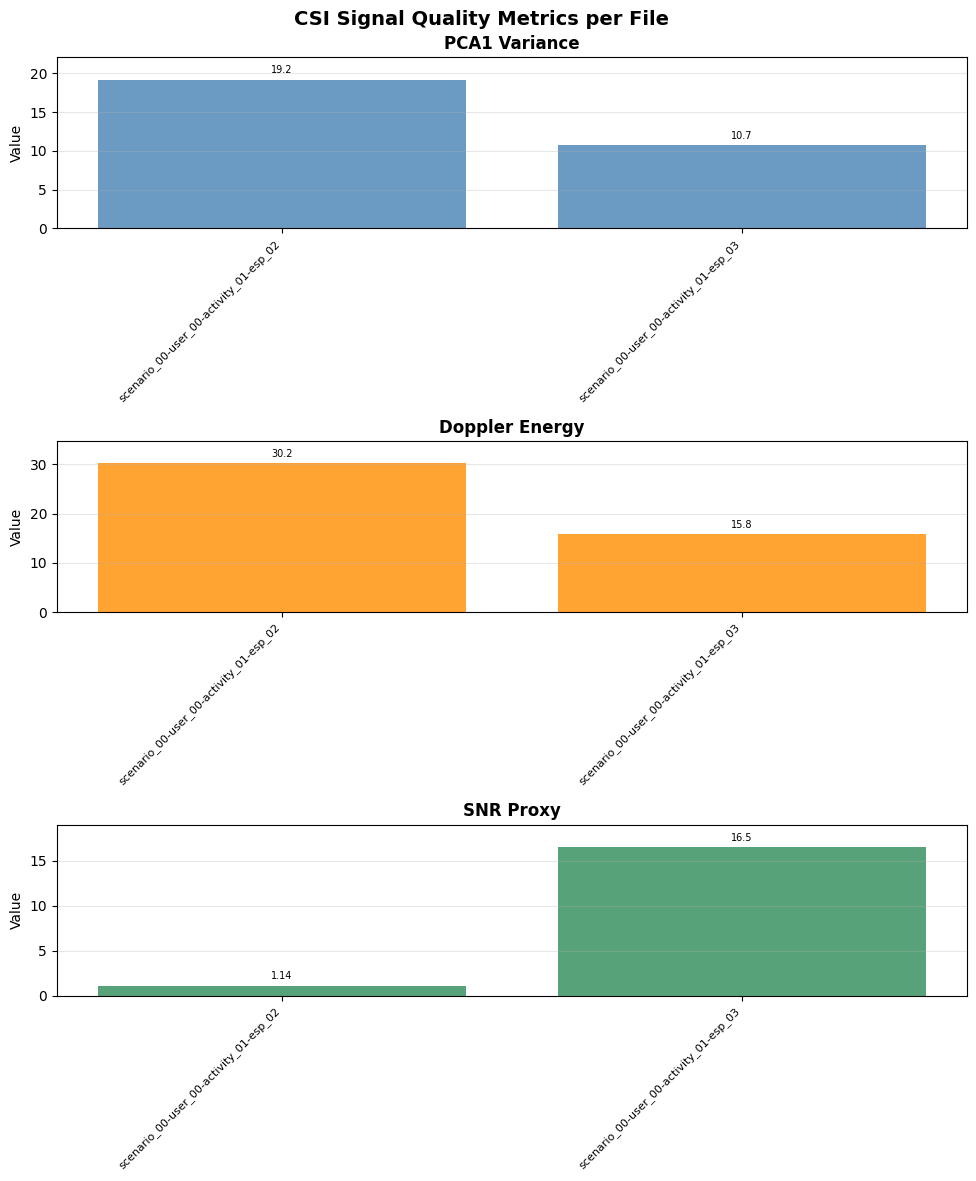

In [7]:
metric_names = ["PCA1 Variance", "Doppler Energy", "SNR Proxy"]
colors = ["steelblue", "darkorange", "seagreen"]
labels = list(metrics_per_file.keys())
x = np.arange(len(labels))

from matplotlib import pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(max(10, len(labels) * 0.8), 12))

for ax, metric, color in zip(axes, metric_names, colors):
    values = [metrics_per_file[lbl][metric] for lbl in labels]
    bars = ax.bar(x, values, color=color, alpha=0.8)
    ax.bar_label(bars, fmt="%.3g", padding=3, fontsize=7)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.margins(y=0.15)

fig.suptitle("CSI Signal Quality Metrics per File", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### CSI Magnitude vs Number of Packages analysis

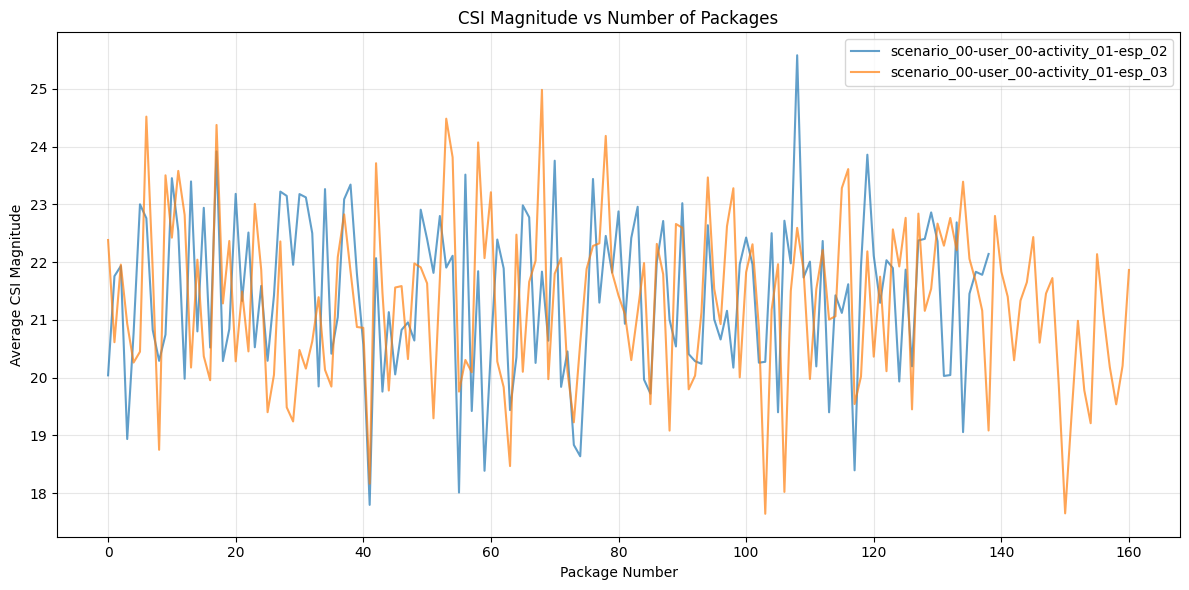

In [8]:
plt.figure(figsize=(12, 6))

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, csi_magnitude in esps_map.items():
				# Calculate average magnitude across all subcarriers for each packet
				avg_magnitude = csi_magnitude.mean(axis=1)
				n_packets = len(avg_magnitude)

				plt.plot(range(n_packets), avg_magnitude, label=f'{user_key}-{activity}-{place}-{esp}', alpha=0.7)

plt.xlabel('Package Number')
plt.ylabel('Average CSI Magnitude')
plt.title('CSI Magnitude vs Number of Packages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Dataset

In [21]:
# função retirada do pipeline da Diana
def segment_signal(
    signal: np.ndarray, window_size: int, overlap: int,
) -> list[np.ndarray]:
    segments: list[np.ndarray] = []

    for i in range(0, signal.shape[0], overlap):
        if i + window_size < signal.shape[0]:
            segment = signal[i : i + window_size]
            segments.append(segment)

    return segments


def process_pipeline(csi_magnitude):
    csi_magnitude = calibrate_magnitude(csi_magnitude)
    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    # parâmetros de segmentação
    # definidos pela Diana
    window_size: int = 10
    overlap_size: int = 2

    segmented_data = segment_signal(pca_features, window_size, overlap_size)
    segmented_data = np.array(segmented_data)

    # Extract features from each window
    window_features = []

    for segment in segmented_data:
        segment_pca1 = segment[:, 0]  # Extract PCA1 from window
        features = [
            np.mean(segment_pca1),      # mean_pca1
            np.var(segment_pca1),       # var_pca1
            np.sum(segment_pca1 ** 2)   # energy_pca1
        ]
        window_features.append(features)

    return np.array(window_features)


def define_x(magnitude):
	user_features = []

	for user_key, activities_map in magnitude.items():
		for activity, esps_map in activities_map.items():
			for esp, csi in esps_map.items():
				print(f"Processing {user_key} - {activity} - {esp}")
				x = process_pipeline(csi)
				user_features.append(x)

	# concatenar apenas junta as matrizes, sem []
	print("user_features: ", user_features)
	user_features = np.concatenate(user_features, axis=0)

	return user_features

In [22]:

# Dataset per scenario
# features | label
# user 00 / act. 00 | 0
# user 01 / act. 01 | 1

# 00   - 00   - 11   - 01
# user - act. - cen. - esp

df_x = []
df_y = []

for scenario_key, users_map in magnitude_data.items():

	print("For scenario: ", scenario_key)
	X_scenario = define_x(users_map)

	df_x.append(X_scenario)


For scenario:  scenario_00
Processing user_00 - activity_01 - esp_02
Processing user_00 - activity_01 - esp_03
user_features:  [array([[-7.92673246e-02,  5.45046187e-02,  6.07879275e-01],
       [-5.65736767e-02,  4.35527204e-02,  4.67533013e-01],
       [-3.91071940e-03,  4.57497192e-02,  4.57650129e-01],
       [ 7.94370066e-02,  3.09244911e-02,  3.72347291e-01],
       [ 1.35612414e-01,  1.99164411e-02,  3.83071679e-01],
       [ 1.98699786e-01,  3.33794484e-03,  4.28195496e-01],
       [ 1.87109917e-01,  5.58367681e-03,  4.05937980e-01],
       [ 1.82648853e-01,  5.07374067e-03,  3.84343442e-01],
       [ 1.78303272e-01,  5.38053762e-03,  3.71725944e-01],
       [ 1.64473652e-01,  3.90973665e-03,  3.09613189e-01],
       [ 1.43378552e-01,  1.63822504e-03,  2.21956342e-01],
       [ 1.55176973e-01,  4.01235640e-04,  2.44811286e-01],
       [ 1.57330602e-01,  6.96299662e-04,  2.54492179e-01],
       [ 1.67034110e-01,  8.56886334e-04,  2.87572802e-01],
       [ 1.82804032e-01,  2.7913